## 导入所需的库

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "4"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import ols
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 保证图表汉字显示正常
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

## 读取数据

In [2]:
df1=pd.read_csv(r'D:\文档\数据分析\Sample - Superstore Source Data.csv',encoding='latin-1')
pd.set_option('display.max_colwidth',None)
df2=pd.read_excel(r'D:\文档\数据分析\Orders_Wide.xlsx')

## 探索性分析

### 检查基本信息

In [3]:
df1.shape

(9994, 21)

In [4]:
df1.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters by Universal,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df2.head()

,Order ID,Order Date,Customer ID,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,is_loss,discount_amount,is_holiday_season
0,CA-2016-152156,2016-11-08,CG-12520,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,0,0.000000,1
1,CA-2016-152156,2016-11-08,CG-12520,South,Furniture,Chairs,731.9400,3,0.00,219.5820,0,0.000000,1
2,CA-2016-138688,2016-06-12,DV-13045,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,0,0.000000,0
3,US-2015-108966,2015-10-11,SO-20335,South,Furniture,Tables,957.5775,5,0.45,-383.0310,1,430.909875,0
4,US-2015-108966,2015-10-11,SO-20335,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,0,4.473600,0


In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
df1.duplicated().sum()

np.int64(0)

In [8]:
df1.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [9]:
df1.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

### 整体利润与销售额

In [10]:
total_sales = df1['Sales'].sum()
total_profit = df1['Profit'].sum()
profit_margin = total_profit / total_sales * 100

print(f"总销售额: {total_sales:,.2f}")
print(f"总利润: {total_profit:,.2f}")
print(f"利润率: {profit_margin:.2f}%")

总销售额: 2,297,200.86
总利润: 286,397.02
利润率: 12.47%


### 归因分析：线性回归

In [11]:
# 控制销售额、品类、地区等变量
model = ols("Profit ~ Discount + Sales + C(Category) + C(Region)", data=df2).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.279
Method:                 Least Squares   F-statistic:                     553.8
Date:                Sat, 23 May 2026   Prob (F-statistic):               0.00
Time:                        16:36:12   Log-Likelihood:                -67073.
No. Observations:                9994   AIC:                         1.342e+05
Df Residuals:                    9986   BIC:                         1.342e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

结论：折扣每增加1个百分点，利润平均下降2。37美元

### 按子类别（Sub-Category）分析利润

In [12]:
# 按子类别计算销售额和利润
subcat = df1.groupby('Sub-Category').agg(
    total_sales = ('Sales', 'sum'),
    total_profit = ('Profit', 'sum')
).reset_index()
# 计算利润率并按利润降序排序
subcat['profit_margin'] = subcat['total_profit'] / subcat['total_sales'] * 100
subcat_sorted = subcat.sort_values('total_profit', ascending=False)
print(subcat_sorted)

   Sub-Category  total_sales  total_profit  profit_margin
6       Copiers  149528.0300    55617.8249      37.195585
13       Phones  330007.0540    44515.7306      13.489327
0   Accessories  167380.3180    41936.6357      25.054700
12        Paper   78479.2060    34053.5693      43.391837
3       Binders  203412.7330    30221.7633      14.857361
5        Chairs  328449.1030    26590.1663       8.095673
14      Storage  223843.6080    21278.8264       9.506113
1    Appliances  107532.1610    18138.0054      16.867517
9   Furnishings   91705.1640    13059.1436      14.240358
7     Envelopes   16476.4020     6964.1767      42.267582
2           Art   27118.7920     6527.7870      24.071083
10       Labels   12486.3120     5546.2540      44.418672
11     Machines  189238.6310     3384.7569       1.788618
8     Fasteners    3024.2800      949.5182      31.396504
15     Supplies   46673.5380    -1189.0995      -2.547695
4     Bookcases  114879.9963    -3472.5560      -3.022768
16       Table

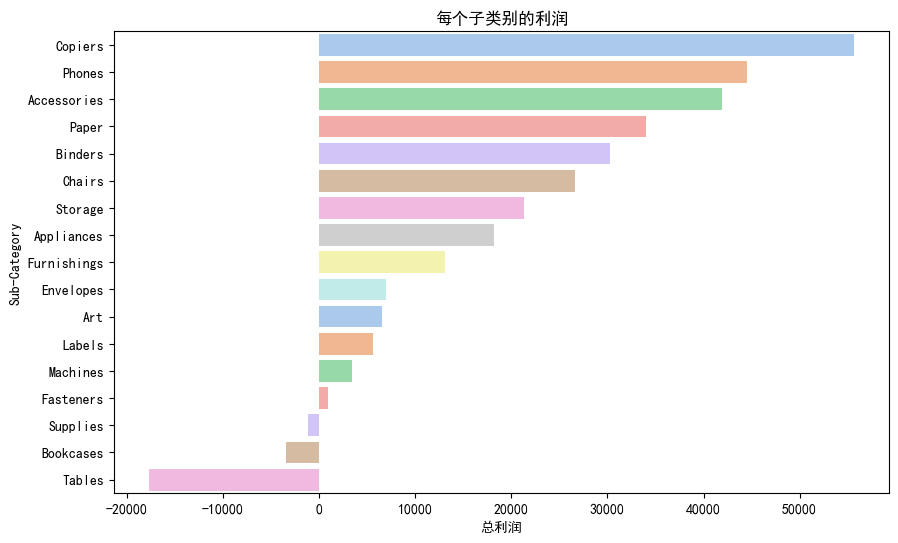

In [13]:
plt.figure(figsize=(10,6))
sns.barplot(data=subcat_sorted, x='total_profit', y='Sub-Category', hue='Sub-Category', palette='pastel', legend=False)
plt.title('每个子类别的利润')
plt.xlabel('总利润')
plt.show()

### 按区域分析

In [14]:
region_profit = df1.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print(region_profit)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


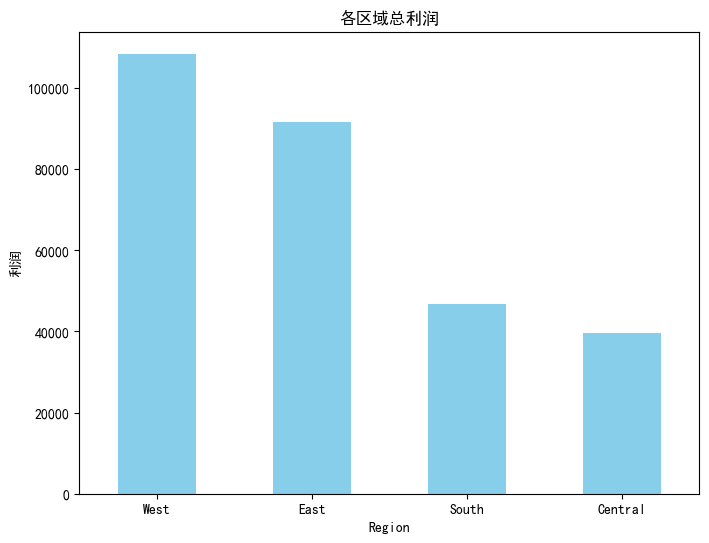

In [15]:
plt.figure(figsize=(8,6))
region_profit.plot(kind='bar', color='skyblue')
plt.title('各区域总利润')
plt.ylabel('利润')
plt.xticks(rotation=0)
plt.show()

### 折扣与利润的关系

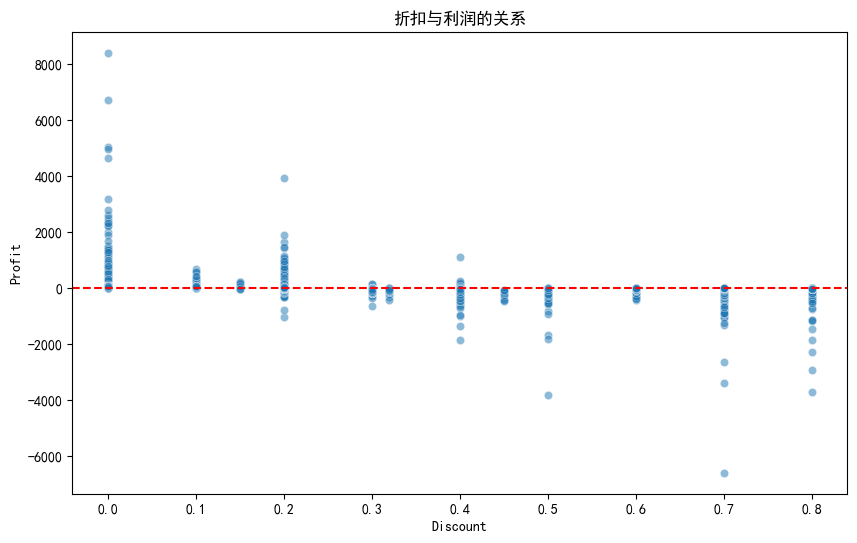

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df1, x='Discount', y='Profit', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('折扣与利润的关系')
plt.savefig('discount_profit.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# 计算不同折扣区间的平均利润
df1['discount_bin'] = pd.cut(
    df1['Discount'], 
    bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 1],  # 这里从0开始
    labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50%+'],
    right=False   # 改为左闭右开
)
discount_profit = df1.groupby('discount_bin',observed=True)['Profit'].mean()
print(discount_profit)

discount_bin
0-10%      66.900292
10-20%     71.562798
20-30%     24.702572
30-40%    -50.237855
40-50%   -117.742680
50%+     -105.277093
Name: Profit, dtype: float64


In [26]:
# 盈利订单（Profit > 0）
profit_df = df1[df1['Profit'] > 0]
# 亏损订单（Profit < 0）
loss_df = df1[df1['Profit'] < 0]

# 平均折扣
avg_discount_profit = profit_df['Discount'].mean()
avg_discount_loss = loss_df['Discount'].mean()

print(f"盈利订单平均折扣: {avg_discount_profit:.2%}")
print(f"亏损订单平均折扣: {avg_discount_loss:.2%}")
print(f"亏损订单的折扣比盈利订单高出: {(avg_discount_loss - avg_discount_profit):.2%}")

盈利订单平均折扣: 8.10%
亏损订单平均折扣: 48.09%
亏损订单的折扣比盈利订单高出: 39.98%


### 时间趋势分析

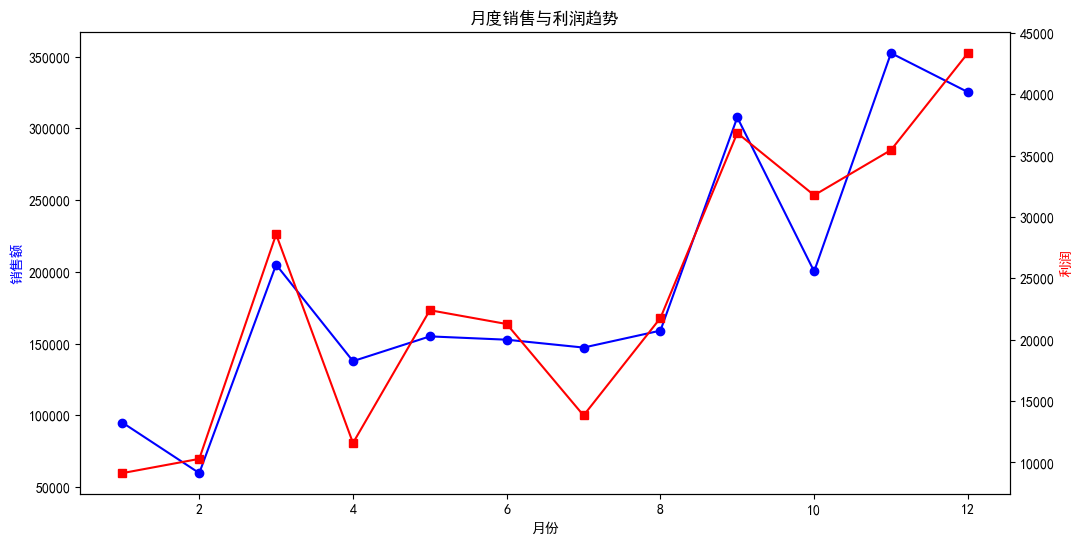

In [27]:
# 将订单时间格式改为datetime
df1['Order Date'] = pd.to_datetime(df1['Order Date'])
df1['Month'] = df1['Order Date'].dt.month

monthly = df1.groupby('Month').agg(
    sales = ('Sales', 'sum'),
    profit = ('Profit', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12,6))
ax2 = ax1.twinx()
ax1.plot(monthly['Month'], monthly['sales'], 'b-o', label='销售额')
ax2.plot(monthly['Month'], monthly['profit'], 'r-s', label='利润')
ax1.set_xlabel('月份')
ax1.set_ylabel('销售额', color='b')
ax2.set_ylabel('利润', color='r')
plt.title('月度销售与利润趋势')
plt.show()

## 深度分析亏损订单

In [28]:
# 筛选亏损订单
loss_df = df1[df1['Profit'] < 0]
print(f"亏损订单数量: {len(loss_df)}  (占比 {len(loss_df)/len(df1)*100:.2f}%)")

# 亏损最多的子类别
loss_by_subcat = loss_df.groupby('Sub-Category')['Profit'].sum().sort_values().reset_index()
print(loss_by_subcat.head())

亏损订单数量: 1871  (占比 18.72%)
  Sub-Category      Profit
0      Binders -38510.4964
1       Tables -32412.1483
2     Machines -30118.6682
3    Bookcases -12152.2060
4       Chairs  -9880.8413


In [29]:
# 先找出亏损子类别的名称列表
loss_subcats = loss_df['Sub-Category'].unique()

# 从原始数据框 df1 中筛选出这些子类别的所有订单
loss_subcat_all = df1[df1['Sub-Category'].isin(loss_subcats)]

# 按子类别分组，计算平均折扣
avg_discount_per_loss_subcat = loss_subcat_all.groupby('Sub-Category')['Discount'].mean().reset_index()
avg_discount_per_loss_subcat.columns = ['Sub-Category', 'avg_discount']
avg_discount_per_loss_subcat = avg_discount_per_loss_subcat.sort_values('avg_discount', ascending=False)

print(avg_discount_per_loss_subcat)

   Sub-Category  avg_discount
2       Binders      0.372292
7      Machines      0.306087
11       Tables      0.261285
3     Bookcases      0.211140
4        Chairs      0.170178
1    Appliances      0.166524
8        Phones      0.154556
6   Furnishings      0.138349
5     Fasteners      0.082028
0   Accessories      0.078452
10     Supplies      0.076842
9       Storage      0.074704


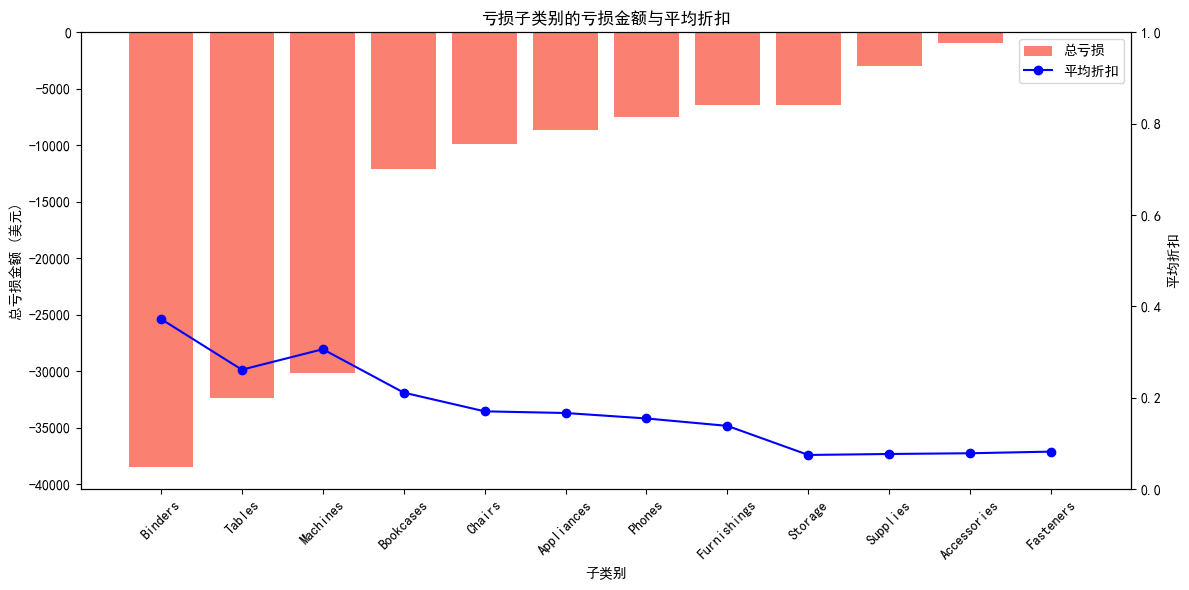

In [30]:
loss_summary = loss_by_subcat.merge(avg_discount_per_loss_subcat, on='Sub-Category')
fig, ax1 = plt.subplots(figsize=(12, 6))

# 垂直柱状图：亏损金额
ax1.bar(loss_summary['Sub-Category'], loss_summary['Profit'], color='salmon', label='总亏损')
ax1.set_xlabel('子类别')
ax1.set_ylabel('总亏损金额 (美元)')
ax1.tick_params(axis='x', rotation=45)

# 次坐标轴：平均折扣折线图
ax2 = ax1.twinx()
ax2.plot(loss_summary['Sub-Category'], loss_summary['avg_discount'], 'o-', color='blue', label='平均折扣')
ax2.set_ylabel('平均折扣')
ax2.set_ylim(0, 1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('亏损子类别的亏损金额与平均折扣')
plt.tight_layout()
plt.savefig('subcat_profit_avg_discount.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# 对于每个亏损子类别，分别计算盈利订单和亏损订单的平均折扣
comparison_list = []
for cat in loss_subcats:
    cat_data = df1[df1['Sub-Category'] == cat]
    profit_orders = cat_data[cat_data['Profit'] > 0]
    loss_orders = cat_data[cat_data['Profit'] < 0]
    
    comparison_list.append({
        'Sub-Category': cat,
        '盈利订单平均折扣': profit_orders['Discount'].mean() if len(profit_orders) > 0 else 0,
        '亏损订单平均折扣': loss_orders['Discount'].mean() if len(loss_orders) > 0 else 0,
        '亏损订单数量': len(loss_orders),
        '总订单数量': len(cat_data)
    })

comparison_df = pd.DataFrame(comparison_list)
comparison_df

,Sub-Category,盈利订单平均折扣,亏损订单平均折扣,亏损订单数量,总订单数量
0,Tables,0.075439,0.365271,203,319
1,Appliances,0.060150,0.800000,67,466
2,Binders,0.125934,0.738010,613,1523
3,Chairs,0.106630,0.261277,235,617
4,Bookcases,0.082479,0.348532,109,228
5,Furnishings,0.053777,0.530539,167,957
6,Storage,0.046596,0.200000,161,846
7,Accessories,0.062079,0.200000,91,775
8,Phones,0.120905,0.342647,136,889
9,Machines,0.135211,0.581818,44,115


结论：即便是同一款产品，亏损订单的折扣也远高于盈利订单，直接证明过度折扣是亏损主因。

## 深度分析与预测

### 随机森林预测亏损订单

In [32]:
# 准备特征和标签
features = ['Discount', 'Sales', 'Quantity', 'Region', 'Category', 'Sub-Category', 'is_holiday_season']
df2_model = pd.get_dummies(df2[features], drop_first=True)
X = df2_model
y = df2['is_loss']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

# 特征重要性
imp = pd.DataFrame({'feature': X.columns, 'importance': clf.feature_importances_}).sort_values('importance', ascending=False)
print(imp.head(10))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1636
           1       0.88      0.84      0.86       363

    accuracy                           0.95      1999
   macro avg       0.92      0.91      0.92      1999
weighted avg       0.95      0.95      0.95      1999

                     feature  importance
0                   Discount    0.568288
1                      Sales    0.191939
2                   Quantity    0.057382
11      Sub-Category_Binders    0.027959
24       Sub-Category_Tables    0.019990
6                Region_West    0.016268
22      Sub-Category_Storage    0.016227
20        Sub-Category_Paper    0.011825
7   Category_Office Supplies    0.009828
3          is_holiday_season    0.009594


折扣（Discount） 的重要性高达 56.8%，远高于其他所有变量

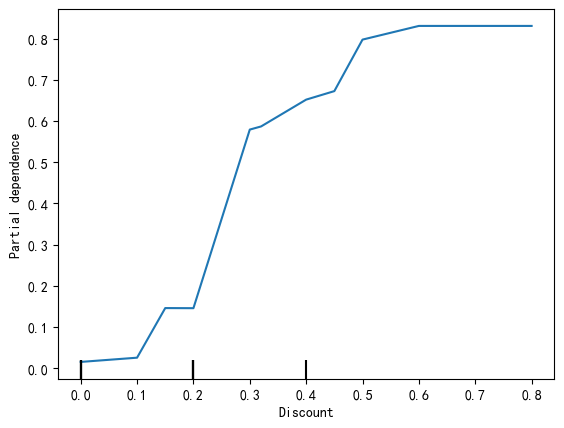

In [33]:
# 折扣从 0% 增加到 50%，亏损概率如何变化
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

PartialDependenceDisplay.from_estimator(clf, X_train, ['Discount'], grid_resolution=50)
plt.show()

折扣超过 20% 后，亏损概率急剧上升

### 客户聚类（KMeans）

In [34]:
# 读取客户 RFM 数据（从 SQL 导出）
cust = pd.read_excel('RFM.xlsx')
cust_scaled = StandardScaler().fit_transform(cust[['recency', 'frequency', 'monetary', 'avg_discount']])

kmeans = KMeans(n_clusters=4, random_state=42)
cust['cluster'] = kmeans.fit_predict(cust_scaled)

# 分析每个簇的平均折扣和利润
cluster_summary = cust.groupby('cluster').agg({
    'avg_discount': 'mean',
    'total_profit': 'mean',
    'recency': 'mean',
    'frequency': 'mean'
}).round(2)
print(cluster_summary)

         avg_discount  total_profit  recency  frequency
cluster                                                
0                0.26        -12.19   103.99       5.43
1                0.15        726.97    82.01       8.95
2                0.15        195.26   574.57       3.80
3                0.09        328.68    99.04       5.35


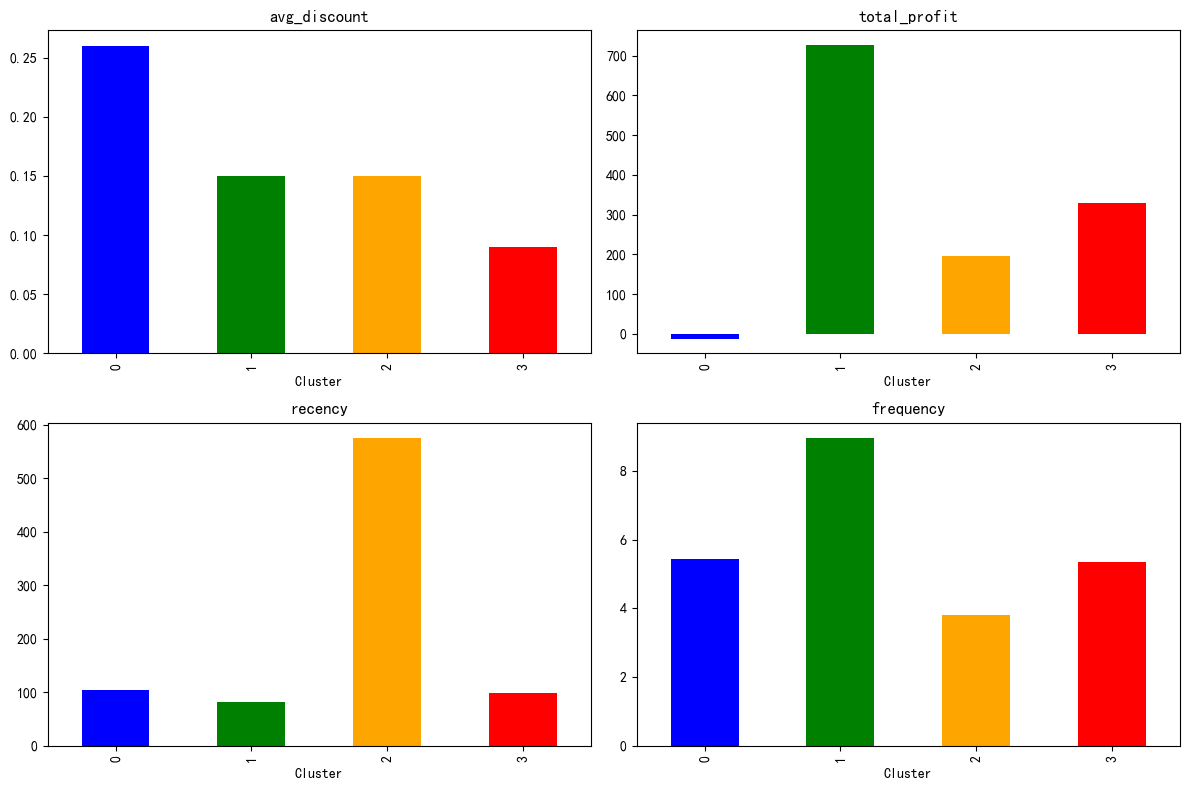

In [35]:
# 可视化
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['avg_discount', 'total_profit', 'recency', 'frequency']
for i, feat in enumerate(features):
    ax = axes[i//2, i%2]
    cluster_summary[feat].plot(kind='bar', ax=ax, color=['blue','green','orange','red'])
    ax.set_title(feat)
    ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

- 簇0（折扣最高0.26，利润唯一为负）属于“高折扣亏损型”，应立刻收紧折扣政策，甚至考虑淘汰这类订单或客户。
- 簇1（折扣适中0.15，利润最高726.97，频率最高8.95，最近购买82天）是最优质的“高价值活跃型”客户，需要重点维护，保持现有折扣水平，并通过忠诚计划提升复购。
- 簇2（折扣同样0.15，但利润较低195.26，近1.6年未购买，频率仅3.8）为“沉睡普通型”，唤醒成本较高，可小成本尝试唤醒活动。
- 簇3（折扣最低0.09，利润良好328.68，中等活跃）为“低折扣稳健型”，说明利润主要不依赖折扣，应维持现有低折扣策略，增加产品曝光以提升购买频率。

高折扣策略会直接导致亏损，而高价值客户的核心特征是对折扣不敏感、购买频率高且近期活跃。